# **Deliverable 3: Ultrasound Physics & Imaging**

---

## Overview

This deliverable covers key concepts from **Lectures 19–24** (Weeks 8–9) of the course. You will explore the complete physics foundation underlying modern ultrasound imaging systems, from fundamental acoustic wave behavior through to clinical image formation and artifact management. Your work will integrate theoretical understanding with computational simulations and experimental design problems.

### Learning Outcomes:

Upon successful completion, you will be able to:
1. **Analyze** acoustic propagation through multi-layer tissue models to predict imaging penetration
2. **Design** ultrasound transducer systems with optimized beam characteristics for specific clinical applications
3. **Implement** ultrasound image reconstruction algorithms from simulated echo data
4. **Evaluate** Doppler measurement feasibility for given tissue depths and velocity ranges
5. **Identify and mitigate** artifacts in ultrasound images through understanding of physics mechanisms
6. **Compare and select** ultrasound imaging modes and parameters for clinical scenarios


---

# Part 1: Acoustic Physics & Tissue Interactions

## Key Concepts

**Impedance & Reflection:** Determines how much sound bounces at tissue boundaries
- Z = ρc (impedance in MRayl) — larger impedance mismatch → stronger reflection
- R = (Z₂ − Z₁)/(Z₂ + Z₁) (pressure reflection coefficient)
- R_I = R² (intensity reflection) — fraction of acoustic energy reflected
- T_I = 4Z₁Z₂/(Z₁+Z₂)² (intensity transmission) — fraction that passes through

**Attenuation:** Signal loss as sound travels through tissue due to absorption and scattering
- Loss = α · frequency · distance (higher frequency attenuates faster)
- α ≈ 0.5–0.8 dB/(cm·MHz) in soft tissue
- Round-trip loss: multiply distance by 2 (sound goes down and back up)
- Total loss in dB = 20·log₁₀(transmitted amplitude / received amplitude)

**Wavelength & Frequency:** Trade-off between resolution and penetration
- λ = c / f (c = 1540 m/s in soft tissue)
- Higher frequency f: shorter wavelength → better resolution but greater attenuation → shallower penetration
- Lower frequency f: longer wavelength → worse resolution but less attenuation → better penetration

## 1.1 Acoustic Impedance & Reflection Analysis

Acoustic impedance, Z = ρc, is the fundamental property determining how sound reflects at tissue boundaries. Ultrasound images are primarily formed from echoes at impedance boundaries.

### **Questions 1**
You are designing an ultrasound probe for cardiac imaging. The probe needs good acoustic coupling between the transducer (Z ≈ 25 MRayl) and skin (Z ≈ 1.54 MRayl). 
- a) Calculate the pressure reflection coefficient at the transducer-skin interface **without coupling gel**. What percentage of energy is lost to reflection (intensity)?
- b) Explain why coupling gel (Z ≈ 1.5 MRayl) improves transmission. Calculate the improvement in transmitted intensity.
- c) Why must matching layers be exactly λ/4 thick to optimally reduce reflections? (Hint: Consider wave interference.)

### **Questions 2**
In abdominal imaging, you encounter three successive tissue boundaries:
1. Skin (ρ = 1100 kg/m³, c = 1700 m/s) → Fat (ρ = 900 kg/m³, c = 1450 m/s)
2. Fat → Muscle (ρ = 1050 kg/m³, c = 1580 m/s)
3. Muscle → Bone cortical (ρ = 1850 kg/m³, c = 3500 m/s)

- a) Calculate Z for each tissue
- b) Calculate reflection coefficients at each boundary
- c) Rank the boundaries by reflection strength. Which is most problematic for imaging?
- d) Why are cortical bone landmarks often clearly visible as "dark shadows" in ultrasound?

In [6]:
# Question 1 - Answers
# a) 
    # assuming no gel means air gap -> Zair = 0 MRayl
    # r = (Zair - Zskin) / (Zair + Zskin)
    # r = (0.0004 - 1.5) / (0.0004 + 1.5)
    # r = -1.4996 / 1.5004
    # r = -0.9995
    # r^2 = 0.9990 -> 99.90% of the ultrasound is reflected at the skin surface without gel
# b)
# coupling gel improves transmission by filling the air gap between the transducer and the skin, allowing acoustic energy to pass through more efficiently. 
# The gel has an acoustic impedance closer to that of the skin, reducing the reflection and increasing the transmission of ultrasound waves into the body.
# As seen above, without gel, 99.90% of the energy is reflected due to air and only 0.10% is transmitted - the transmission with gel is calculated below.
    # Ztransducer(25 MRayl) to Zgel (gel = 1.5 MRayl)
    # r = (Zgel - Ztransducer) / (Zgel + Ztransducer)
    # r = (1.5 - 25) / (1.5 + 25)
    # r = -23.5 / 26.5
    # r = -0.8868
    # r^2 = 0.7864 -> 78.64%
        # transmitted intensity = 100% - reflected intensity 
        # T1 = 100% - 78.64% = 21.36%
        # T1 = 0.2136
    # Zgel (1.5 MRayl) to Zskin (1.54 MRayl)
    # r = (Zskin - Zgel) / (Zskin + Zgel)
    # r = (1.54 - 1.5) / (1.54 + 1.5)
    # r = 0.04 / 3.04
    # r = 0.0132
    # r^2 = 0.0002 -> 0.02% 
        # transmitted intensity = 100% - reflected intensity
        # T2 = 100% - 0.02% = 99.98%
        # T2 = 0.9998
    # Total transmitted intensity = T1 * T2
    # Total transmitted intensity = 0.2136 * 0.9998
    # Total transmitted intensity = 0.2135 -> 21.35% of the ultrasound is transmitted into the skin with gel
# c)
    # Matching layers help improve the transmission of ultrasound by reducing the reflections caused by impedance mismatches between the transducer and the skin.
    # By ensuring layers are exactly λ/4 thick, the wave reflected from the first interface will be out of phase with the wave reflected from the second interface,
    # causing the wave of the second interface to travel an additional λ/2 distance, casuing a 180º phase shift and destructive interference - causing the reflected
    # waves to cancel each other out and allowing more energy to be transmitted into the body, minimizing the net reflection.

# Question 2 - Answers
# a)
    # Skin: p = 1100 kg/m^3, c = 1700 m/s
        # Zskin = p * c
        # Zskin = 1100 kg/m^3 * 1700 m/s
        # Zskin = 1,870,000 kg/(m^2*s) = 1.87 MRayl
    # Fat: p = 900 kg/m^3, c = 1450 m/s
        # Zfat = p * c
        # Zfat = 900 kg/m^3 * 1450 m/s
        # Zfat = 1,305,000 kg/(m^2*s) = 1.305 MRayl
    # Muscle: p = 1050 kg/m^3, c = 1580 m/s
        # Zmuscle = p * c
        # Zmuscle = 1050 kg/m^3 * 1580 m/s
        # Zmuscle = 1,659,000 kg/(m^2*s) = 1.659 MRayl
    # Bone: p = 1850 kg/m^3, c = 3500 m/s
        # Zbone = p * c
        # Zbone = 1850 kg/m^3 * 3500 m/s
        # Zbone = 6,475,000 kg/(m^2*s) = 6.475 MRayl
# b)
    # Zskin to Zfat
        # r = (Zfat - Zskin) / (Zfat + Zskin)
        # r = (1.305 - 1.87) / (1.305 + 1.87)
        # r = -0.565 / 3.175
        # r = -0.1779
    # Zfat to Zmuscle
        # r = (Zmuscle - Zfat) / (Zmuscle + Zfat)
        # r = (1.659 - 1.305) / (1.659 + 1.305)
        # r = 0.354 / 2.964
        # r = 0.1195
    # Zmuscle to Zbone
        # r = (Zbone - Zmuscle) / (Zbone + Zmusle)
        # r = (6.475 - 1.659) / (6.475 + 1.659)
        # r = 4.816 / 8.134
        # r = 0.5918
# c)
    # Ranked by reflection strength (|R|) (from strongest to weakest):
        # Zmuscle to Zbone (r = 0.5918)
        # Zskin to Zfat (r = 0.1779)
        # Zfat to Zmuscle (r = 0.1195)
    # The most problematic boundary for imaging is the muscle to bone boundary, as it has the highest reflection strength meaning a significant
    # portion of the ultrasound energy will be reflected back, reducing the amount of energy that penetrates into the bone and potentially 
    # obscuring details in the image.
# d)
    # cortical bone landmarks are visible as dark shadows in the ultrasound image because they have a much higher acoustic impedance than soft tissue.
    # When ultrasound waves make contact with the cortical bone, most of the acoustic energy is reflected at the bone surface - preventing the waves from
    # penetrating deeper into the bone tissue. This results in a strong echo that appears as a bright line on the ultrasound image, while the area behind 
    # the cortical bone appears dark due to the lack of transmitted ultrasound waves, creating a shadow effect.

## 1.2 Multi-Layer Tissue Transmission Model

Ultrasound must penetrate through multiple tissue layers to reach target organs. Both reflection losses at each interface and attenuation within each tissue layer reduce the overall signal strength. This analysis predicts whether adequate signal will return for imaging.

### **Coding Exercise 1**

Implement a function to calculate total round-trip transmission through multiple tissue layers, accounting for:
1. **Interface losses:** Reflection loss at each boundary between different tissues
2. **Attenuation losses:** Frequency-dependent signal loss as sound propagates through each layer (round-trip)

Return the overall transmission loss in dB and identify the dominating loss mechanism(s).

In [2]:
# TODO: Define tissue properties (impedance, attenuation coefficient, thickness)
import math

def calculate_round_trip_loss(layers, frequency):
    reflection_loss_dB = 0
    attenuation_loss_dB = 0
    interface_losses = []
    layer_losses = []
    
    # TODO: Calculate reflection losses at each interface
    for i in range(len(layers) - 1):
        Z1 = layers[i]['Z']
        Z2 = layers[i + 1]['Z']
        T_I = 4 * Z1 * Z2 / ((Z1 + Z2) ** 2)
        T_rt = T_I ** 2
        loss_dB = -10 * math.log10(T_rt)
        reflection_loss_dB += loss_dB
        interface_losses.append((f"Interface {i} to {i+1}", loss_dB))

    # TODO: Report total loss in dB and identify dominant mechanism
    for i, layer in enumerate(layers):
        loss_dB = layer['alpha'] * frequency * 2 * layer['thickness']  
        attenuation_loss_dB += loss_dB
        layer_losses.append((f"Layer {i}", loss_dB))

    total_loss_dB = reflection_loss_dB + attenuation_loss_dB

    if reflection_loss_dB > attenuation_loss_dB:
        dominant = "Reflection losses at interfaces"
    elif attenuation_loss_dB > reflection_loss_dB:
        dominant = "Attenuation losses within tissues"
    else:
        dominant = "Both reflection and attenuation losses are comparable"
    return {
        "reflection_loss_dB": reflection_loss_dB,
        "attenuation_loss_dB": attenuation_loss_dB,
        "total_loss_dB": total_loss_dB,
        "dominant_mechanism": dominant,
        "interface_losses": interface_losses,
        "layer_losses": layer_losses
    }

# Define tissue properties
layers = [
    {'Z': 1.87, 'alpha': 0.5, 'thickness': 0.2},  # Skin
    {'Z': 1.305, 'alpha': 0.6, 'thickness': 2.0},  # Fat
    {'Z': 1.659, 'alpha': 0.7, 'thickness': 3.0},  # Muscle
    {'Z': 6.475, 'alpha': 2.0, 'thickness': 1.0}   # Bone
]

frequency = 5  # MHz

result = calculate_round_trip_loss(layers, frequency)

# TODO: Calculate attenuation losses through each layer (round-trip)
print(f"Total reflection loss (round-trip): {result['reflection_loss_dB']:.2f} dB")
print(f"Total attenuation loss (round-trip): {result['attenuation_loss_dB']:.2f} dB")
print(f"Overall transmission loss: {result['total_loss_dB']:.2f} dB")
print(f"Dominant loss mechanism: {result['dominant_mechanism']}")

Total reflection loss (round-trip): 4.15 dB
Total attenuation loss (round-trip): 54.00 dB
Overall transmission loss: 58.15 dB
Dominant loss mechanism: Attenuation losses within tissues


## 1.3 Clinical Penetration Analysis

### **Questions 3**

You are choosing the operating frequency for obstetric ultrasound in a pregnant patient at different gestational ages.
- a) **First Trimester (up to 3 cm depth through maternal tissue):** Compare 10 MHz vs. 5 MHz
  - Calculate expected round-trip loss through skin (0.2 cm) + adipose (2 cm) at both frequencies
  - Which frequency is better and why?

- b) **Third Trimester (6–8 cm depth):** Should you switch to a lower frequency? Estimate the penetration limit at 3.5 MHz (typical for this scenario).

### **Questions 4**

Abdominal imaging in an obese patient requires imaging through 5 cm of additional adipose tissue. Assuming a 2–5 MHz transducer:
- a) How much additional loss (in dB) occurs due to the extra fat layer?
- b) What compensatory adjustments to transducer power might be necessary?
- c) Why might harmonic imaging be attractive here despite resolution trade-offs?

In [ ]:
# Question 3 - Answers
# a)
    # round-trip attenuation loss at 10 MHz 
        # skin (attenuation coefficient = 0.5 dB/cm/MHz * 10 MHz = 5 dB/cm): 
            # attenuation loss = 2 * alpha * depth
            # attenuation loss = 2 * 5 dB/cm * 0.2 cm
            # attenuation loss = 2 dB
        #adipose (attenuation coefficient = 0.63 dB/cm/MHz * 10 MHz = 6.3 dB/cm):
            # attenuation loss = 2 * alpha * depth
            # attenuation loss = 2 * 6.3 dB/cm * 2 cm
            # attenuation loss = 25.2 dB
        # total attenuation loss = 2 dB + 25.2 dB = 27.2 dB
    # round-trip attenuation loss at 5 MHz (attenuation coefficient at 5 MHz = 0.5 dB/cm/MHz * 5 MHz = 2.5 dB/cm)
        # skin (attenuation coefficient = 0.5 dB/cm/MHz * 5 MHz = 2.5 dB/cm):
            # attenuation loss = 2 * alpha * depth
            # attenuation loss = 2 * 2.5 dB/cm * 0.2 cm
            # attenuation loss = 1 dB
        # adipose (attenuation coefficient = 0.63 dB/cm/MHz * 5 MHz = 3.15 dB/cm):
            # attenuation loss = 2 * alpha * depth
            # attenuation loss = 2 * 3.15 dB/cm * 2 cm
            # attenuation loss = 12.6 dB
        # total attenuation loss = 1 dB + 12.6 dB = 13.6 dB
    # 5 MHz is better for penetration in the first trimester as it has a lower attenuation loss compared to 10 MHz, allowing more ultrasound 
    # energy to reach deeper structures in the body, which is crucial for imaging during early pregnancy when the fetus is smaller and located 
    # deeper within the uterus. While 10 MHz may provide better axial resolution, because attenuation increases linearly with frequency, the
    # 10 MHz probe would result in ~2x more loss compared to the 5 MHz probe which offers sufficient resolution while minimizing signal loss
    # ensuring adequate echo return for clear imaging of the developing fetus.
# b)
    # Yes you should switch to a lower frequency for third trimester imaging - deeper penetration (6-8 cm vs 0-3 cm) requires you to balance
    # both resolution and attenuation increased frequencies would attenuate too quickly (loss becomes proportional to frequency) which would
    # reduce the amplitude of the returining echoes and degrade image quality. Using the lower frequency does sacrifice some resolution, but 
    # it allows for better visualization of deeper structures in the third trimester, ensuring that important anatomical details can still be 
    # observed while maintaining sufficient image quality.
        # penetration limit estimate at 3.5 MHz (attenuation coefficient at 3.5 MHz = 0.5 dB/cm/MHz * 3.5 MHz = 1.75 dB/cm):
            # assuming ~7 cm depth, alpha = 1.75 dB/cm
            # attenuation loss = 2 * alpha * depth
            # attenuation loss = 2 * 1.75 dB/cm * 7 cm
            # attenuation loss = 24.5 dB
# Question 4 - Answers
# a)
    # additional round-trip loss - assuming adipose attenuation coefficient = 0.63 dB/cm/MHz
        # at 2 MHz, attenuation coefficient = 0.63 dB/cm/MHz * 2 MHz = 1.26 dB/cm, depth = 5 cm
            # attenuation loss = 2 * alpha * depth
            # attenuation loss = 2 * 1.26 dB/cm * 5 cm
            # attenuation loss = 12.6 dB
        # at 5 MHz, attenuation coefficient = 0.63 dB/cm/MHz * 5 MHz = 3.15 dB/cm, depth = 5 cm
            # attenuation loss = 2 * alpha * depth 
            # attenuation loss = 2 * 3.15 dB/cm * 5 cm
            # attenuation loss = 31.5 dB
        # range = 12.6 dB to 31.5 dB additional loss depending on exact frequency used
# b)
    # you could increase transmission power to boost the amplitude of the echo by the additional loss, but this may not be safe for the patient 
    # and could lead to overheating of the tissue. you could also switch to a lower frequency within the 2-5 MHz range to reduce attenuation
    # however this would come at the cost of lower resolution. Another option is to use a probe with a larger aperture to increase the 
    # signal-to-noise ratio, but this may not be feasible in all clinical settings. time gain compensation (TGC) can also be used to amplify the 
    # returning echoes from deeper tissues, but this may not fully compensate for the increased attenuation and could lead to a noisier image, 
    # and you would still need to adjust the power output as it is integral for maintaining SNR.
# c)
    # harmonic imaging is attractive in this scenario because it uses the nonlinear properties of tissue to generate higher frequency harmonics
    # which can provide better resolution while still allowing for deeper penetration compared to the fundamental frequency. and because these
    # second-harmonic echoes are less affected by near-field artifact and tissue inhomogeneities which are common in adipose tissue, it can 
    # improve image contrast and reduce artifacts despite having a worse resolution compared to conventional imaging. Harmonics provide cleaner
    # images at deeper penetrations which fundamental modes are not able to achieve. by supressing low-frequency noise cleaner images can be
    # obtained which makes it easier to visualize structures that may be obscured by the increased attenuation in adipose tissue despire the
    # penalty to axial resolution.


---

# Part 2: Transducers & Beam Forming

## Key Concepts
**Wavelength & Element Spacing:** Fundamental limitation for phased arrays
- λ = c / f (c = 1540 m/s)
- Element spacing s ≤ λ/2 — prevents unwanted secondary lobes (grating lobes)

**Beam Geometry:** How the acoustic beam spreads and focuses
- Near-field length: N = D²/(4λ) where D = aperture diameter — distance from transducer to focal point
- Far-field divergence angle: θ ≈ λ/D (radians) — beam spreads beyond focal point
- Lateral resolution at focal depth: ≈ λ·z/D (z = focal depth) — tightest beam at focal point

**Axial Resolution:** Along the beam direction, determined by pulse length
- δz = (c · τ) / 2 where τ = pulse duration — shorter pulses give better resolution
- Trade-off: shorter pulses require wider bandwidth, which reduces signal-to-noise ratio

**Focal Zone:** Where beam is narrowest and lateral resolution is best
- Lateral resolution is excellent at focal depth, degrades in near field and far field
- Multiple focal zones (electronic or mechanical) improve coverage but reduce frame rate

## 2.1 Transducer Design & Near-Field Analysis

### **Questions 5**

You are designing a linear array transducer for abdominal imaging. Frequency: 5 MHz, Desired penetration: 15 cm, Focal zone: ~4 cm
- a) Calculate the wavelength in soft tissue at 5 MHz (c = 1540 m/s)
- b) What is the minimum element spacing to avoid grating lobes (phased array constraint)?
- c) To achieve 4 cm focal zone, what aperture diameter (number of active elements) is required? (Hint: N = D²/(4λ))
- d) Compare a 64-element vs 128-element array: which has better lateral resolution and why?

### **Questions 6**

A 7.5 MHz transducer for cardiac imaging through intercostal spaces has a diameter of 12 mm.
- a) Calculate the near-field length
- b) Calculate the far-field divergence angle
- c) Can this transducer achieve useful resolution at 10 cm depth (typical mitral valve location)? Why or why not?

In [ ]:
# Question 5 - Answers
# a)
    # wavelength in soft tissue at 5 MHz:
        # λ = c / f
        # λ = 1540 m/s / (5 x 10^6) Hz
        # λ = 0.000308 m = 0.308 mm
# b)
    # The minimum element spacing to avoid grating lobes can be calculated using the formula: 
        # s_min = λ / 2
        # s_min = 0.308 mm / 2
        # s_min = 0.154 mm
# c)
    # Aperature diameter given N = 4 cm (40 mm) and λ = 0.308 mm:
        # N = D^2/(4λ)
        # D^2 = 4λN
        # D^2 = 4 * 0.308 mm * 40 mm
        # D^2 = 49.28 mm^2
        # D = sqrt(49.28 mm^2)
        # D = 7.02 mm
# d)
    # assuming that pitch is equal to element spacing, the number of elements for each display are:
        # 64 element display:
            # D = N_elements * s_min
            # D = 64 * 0.154 mm
            # D = 9.856 mm
            # N = D^2/(4λ)
            # N = (9.856 mm)^2 / (4 * 0.308 mm)
            # N = 78.8 
        # 128 element display:
            # D = N_elements * s_min
            # D = 128 * 0.154 mm
            # D = 19.712 mm
            # N = D^2/(4λ)
            # N = (19.712 mm)^2 / (4 * 0.308 mm)
            # N = 315.2
    # the 128 element display provides better lateral resolution due to the larger size of the aperature
    # compared to the 64 element display which has better near-field resolution but worse far-field. because
    # resolution degrades less as D increases, the 128 element display would offer better lateral resolution
    # at depth compared to the 64.
# Question 6 - Answers
# a)
    # Frequency = 7.5 MHz, D = 12 mm
    # λ = c / f
    # λ = 1540 m/s / (7.5 x 10^6) Hz
    # λ = 0.000205 m = 0.205 mm
    # Near-field length = D^2 / (4λ)
    # N = (12 mm)^2 / (4 * 0.205 mm)
    # N = 175.6 mm = 17.56 cm
# b)
    # Far-field divergence angle: 
    # θ = λ / D
    # θ = 0.205 mm / 12 mm
    # θ = 0.0171 radians = 0.98 degrees
# c)
    # yes this transducer can achieve useful resolution at 10 cm depth because the near-field length of
    # 17.56 cm is greater than 10 cm, meaning that the structure would be within the near-field region where
    # the beam is more focused and can provide better resolution. also, the far-field divergence angle of
    # 0.98º is small enough that a narrow beam can be maintained at this depth providing good lateral
    # resolution as well.




## 2.2 Electronic Beam Steering & Focusing

### **Coding Exercise 2**

Implement a phased array beam-forming simulator. Calculate the time delays required to:
1. **Focus the transmit beam** at a specified focal depth
2. **Steer the beam** to a specified angle
3. **Simulate receive beam forming** by applying delays to received signals

Visualize the resulting beam pattern and assess the impact of different arrays (64 vs 128 elements) and frequencies.

Wavelength: 0.308 mm
Delay range (us): 0.85


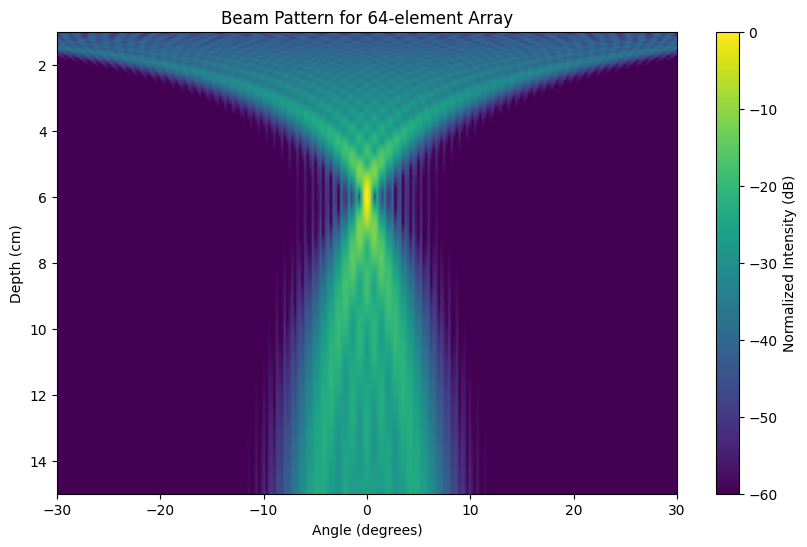

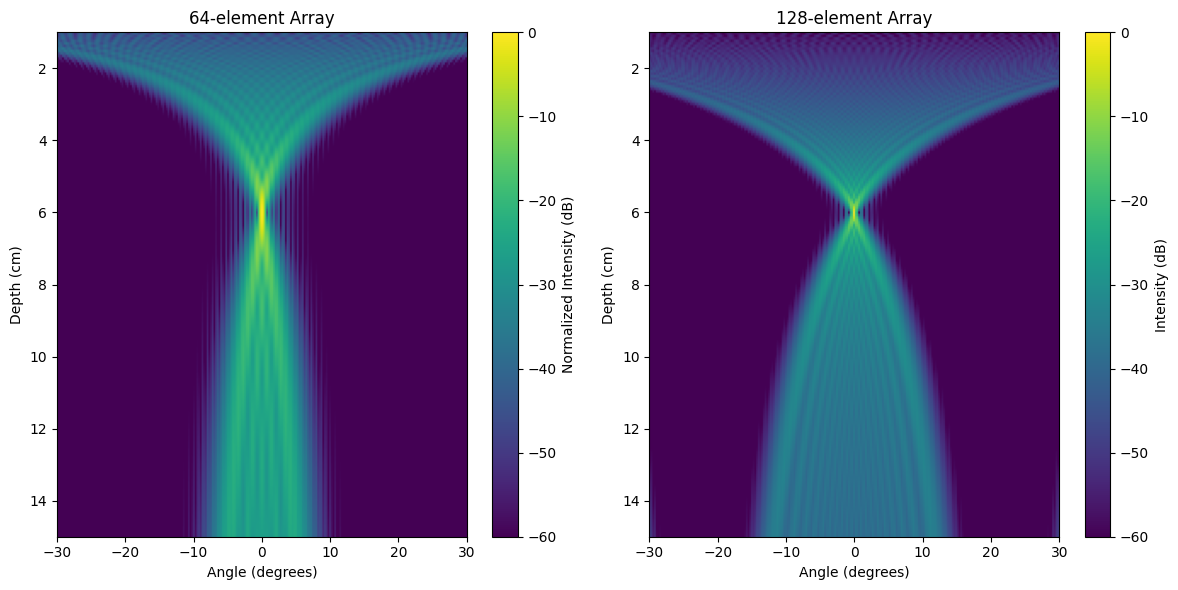

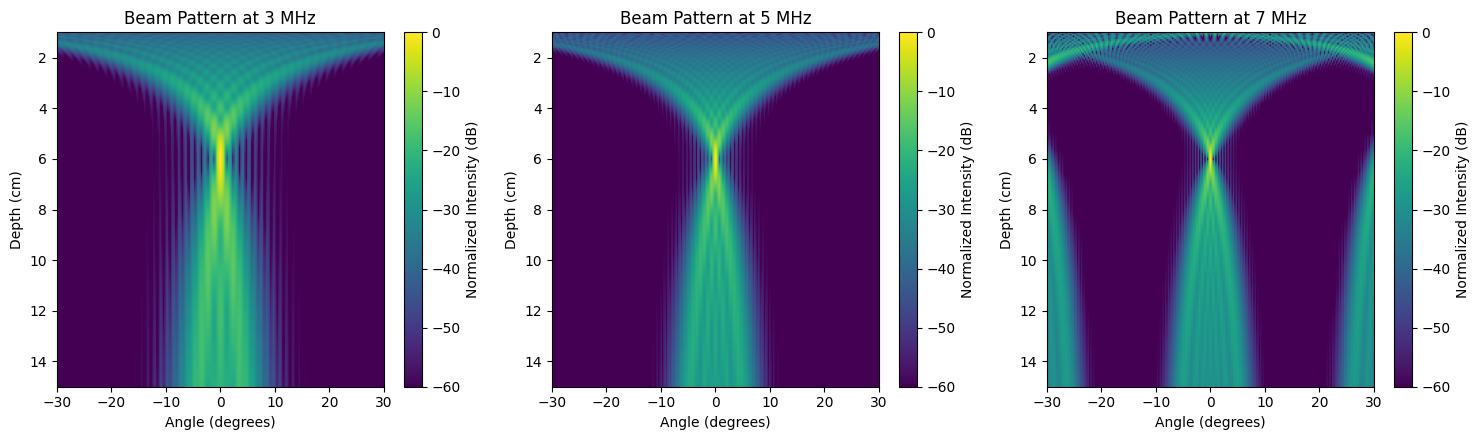

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Calculate wavelength and element positions
# TODO: Calculate transmit delays for focusing and steering

element_spacing_mm = 0.4
c = 1540  
frequency = 5 * 1e6  
 


def get_array_geometry(num_elements, element_spacing_mm):
    element_spacing = element_spacing_mm * 1e-3  
    array_length = (num_elements - 1) * element_spacing
    element_positions = np.linspace(-array_length/2, array_length/2, num_elements)
    return element_positions, element_spacing

num_elements = 64  
element_positions, element_spacing = get_array_geometry(num_elements, element_spacing_mm)
wavelength = c / frequency 
focal_depth = 0.06 
steering_angle = 0

# TODO: Calculate transmit delays for focusing at specified depth
def calculate_focus_delays(element_positions, focal_depth, c):
    delays = np.zeros(len(element_positions))
    for i, x in enumerate(element_positions):
        distance = np.sqrt(x**2 + focal_depth**2)
        delays[i] = distance / c
    delays -= np.min(delays)  
    return delays

focus_delays = calculate_focus_delays(element_positions, focal_depth, c)

# TODO: Calculate transmit delays for beam steering at specified angle
def calculate_steer_delays(element_positions, steering_angle, c):
    angle_rad = np.deg2rad(steering_angle)
    delays = (element_positions * np.sin(angle_rad)) / c
    delays -= np.min(delays)
    return delays

steer_delays = calculate_steer_delays(element_positions, steering_angle, c)


transmit_delays = focus_delays + steer_delays

print(f"Wavelength: {wavelength*1e3:.3f} mm")
print(f"Delay range (us): {np.ptp(transmit_delays)*1e6:.2f}")

# TODO: Simulate and visualize beam patterns
def simulate_beam_pattern(element_positions, delays, frequency, depth_range, angle_range, c):
    k = 2 * np.pi * frequency / c 

    if depth_range is None:
        depths = np.linspace(0.01, 0.15, 200)
    else:
        depths = depth_range
    if angle_range is None:
        angles = np.linspace(-30, 30, 241)
    else:
        angles = angle_range
    beam_pattern = np.zeros((len(depths), len(angles)))
    
    for i, z in enumerate(depths):
        for j, theta in enumerate(angles):
            theta_rad = np.deg2rad(theta)
            x_field = z * np.tan(theta_rad)

            tx_sum = 0j
            rx_sum = 0j

            for pos, delay in zip(element_positions, delays):
                distance = np.sqrt((x_field - pos)**2 + z**2)

                tx_phase = k * distance - 2 * np.pi * frequency * delay
                tx_sum += np.exp(1j * tx_phase)

                rx_phase = k * distance - 2 * np.pi * frequency * delay
                rx_sum += np.exp(1j * rx_phase)
            beam_pattern[i, j] = np.abs(tx_sum * rx_sum)
    
    beam_pattern /= np.max(beam_pattern)
    beam_pattern_dB = 20 * np.log10(beam_pattern + 1e-10)
    
    return depths, angles, beam_pattern_dB

depths, angles, beam_pattern = simulate_beam_pattern(element_positions, transmit_delays, frequency, None, None, c)

plt.figure(figsize=(10, 6))
plt.imshow(
    beam_pattern,
    extent=[angles[0], angles[-1], depths[-1]*100, depths[0]*100],
    aspect='auto',
    cmap='viridis',
    vmin = -60,
    vmax = 0
)
plt.colorbar(label='Normalized Intensity (dB)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Depth (cm)')
plt.title('Beam Pattern for 64-element Array')
plt.show()

# TODO: Compare different array configurations (64 vs 128 elements)

def compare_arrays(num_elements, element_spacing, focal_depth, steering_angle, frequency, c):
    array_length = (num_elements - 1) * element_spacing
    positions = np.linspace(-array_length/2, array_length/2, num_elements)

    focus_delays = calculate_focus_delays(positions, focal_depth, c)
    steer_delays = calculate_steer_delays(positions, steering_angle, c)
    delays = focus_delays + steer_delays

    depths, angles, beam_pattern = simulate_beam_pattern(
        positions, delays, frequency, None, None, c)
    return depths, angles, beam_pattern

depths_64, angles_64, beam_pattern_64 = compare_arrays(
64, element_spacing, focal_depth, steering_angle, frequency, c
)

depths_128, angles_128, beam_pattern_128 = compare_arrays(
    128, element_spacing, focal_depth, steering_angle, frequency, c)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(
    beam_pattern_64,
    extent =[angles_64[0], angles_64[-1], depths_64[-1]*100, depths_64[0]*100],
    aspect='auto',
    cmap='viridis',
    vmin = -60,
    vmax = 0
)
plt.colorbar(label='Normalized Intensity (dB)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Depth (cm)')
plt.title('64-element Array')

plt.subplot(1, 2, 2)
plt.imshow(
    beam_pattern_128,
    extent=[angles_128[0], angles_128[-1], depths_128[-1]*100, depths_128[0]*100],
    aspect='auto',
    cmap='viridis',
    vmin = -60,
    vmax = 0
)
plt.colorbar(label='Intensity (dB)')
plt.xlabel('Angle (degrees)')
plt.ylabel('Depth (cm)')
plt.title('128-element Array')

plt.tight_layout()
plt.show()

# TODO: Compare different frequencies
frequencies = [3e6, 5e6, 7e6]
frequency_labels = ['3 MHz', '5 MHz', '7 MHz']

plt.figure(figsize=(15, 4.5))

for idx, freq in enumerate(frequencies):
    wavelength = c / freq
    focus_delays = calculate_focus_delays(element_positions, focal_depth, c)
    steer_delays = calculate_steer_delays(element_positions, steering_angle, c)
    delays = focus_delays + steer_delays

    depths_freq, angles_freq, beam_pattern_freq = simulate_beam_pattern(
        element_positions, delays, freq, None, None, c)
    
    plt.subplot(1, 3, idx + 1)
    plt.imshow(
        beam_pattern_freq,
        extent=[angles_freq[0], angles_freq[-1], depths_freq[-1]*100, depths_freq[0]*100],
        aspect='auto',
        cmap='viridis',
        vmin = -60,
        vmax = 0
    )
    plt.colorbar(label='Normalized Intensity (dB)')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Depth (cm)')
    plt.title(f'Beam Pattern at {frequency_labels[idx]}')

plt.tight_layout()
plt.show()

## 2.3 Lateral Resolution Across Focal Zone

### **Questions 7**

A 5 MHz linear array with 128 elements and 0.4 mm spacing is used for abdominal imaging with an electronic focal depth of 6 cm.
- a) Calculate the lateral resolution at the focal depth
- b) Calculate the lateral resolution at 1 cm (near field) and 15 cm (far field)
- c) Plot lateral resolution vs depth. At what depths does lateral resolution exceed (degrade beyond) 1 mm?
- d) How could you improve lateral resolution at 15 cm depth? What are the trade-offs of each approach?

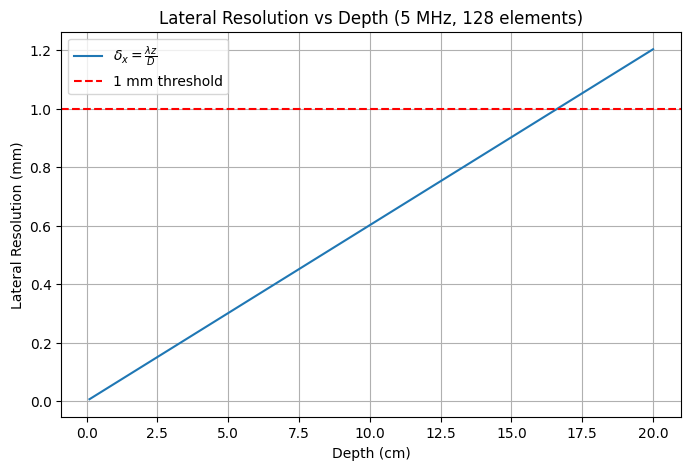

In [2]:
# Question 7 - Answers
# a)
    # f = 5 MHz, N = 128, s = 0.4 mm, D = 6 cm
    # lateral resolution at 6 cm depth:
        # λ = c / f
        # λ = 1540 m/s / (5 x 10^6) Hz
        # λ = 0.000308 m = 0.308 mm
        # Aperature width
        # D = N * s
        # D = 128 * 0.4 mm
        # D = 51.2 mm 
        # Lateral resolution
        # Δx = λ * z / D
        # Δx = 0.308 mm * 60 mm / 51.2 mm
        # Δx = 0.361 mm
# b)
    # f = 5 MHz, N = 128, s = 0.4 mm, near-field = 1 cm, far-field = 15 cm
    # lateral resolution at 1 cm depth (assuming same scaling as above):
        # Δx = λ * z / D
        # Δx = 0.308 mm * 10 mm / 51.2 mm
        # Δx = 0.060 mm
    # lateral resolution at 15 cm depth (assuming same scaling as above):
        # Δx = λ * z / D
        # Δx = 0.308 mm * 150 mm / 51.2 mm
        # Δx = 0.902 mm
# c)
# z when Δx exceeds 1 mm (depth at which resolution degrades beyond 1 mm):
    # Δx = λ * z / D
    # 1 mm = 0.308 mm * z / 51.2 mm
    # z = (1 mm * 51.2 mm) / 0.308 mm
    # z = 166.23 mm = 16.62 cm

import numpy as np
import matplotlib.pyplot as plt

lambda_mm = 0.308  
D_mm = 51.2  
z_cm = np.linspace(0.1, 20, 200)  
z_mm = z_cm * 10  

delta_x_mm = (lambda_mm * z_mm) / D_mm


plt.figure(figsize=(8, 5))
plt.plot(z_cm, delta_x_mm, label=r'$\delta_x = \frac{\lambda z}{D}$')
plt.axhline(y=1.0, color='red', linestyle='--', label='1 mm threshold')
plt.xlabel('Depth (cm)')
plt.ylabel('Lateral Resolution (mm)')
plt.title('Lateral Resolution vs Depth (5 MHz, 128 elements)')
plt.legend()
plt.grid(True)
plt.show()

# d)
    # lateral resolution at 15 cm depth could be improved by increasing the size of the aperature (D) or by
    # increasing the frequency - which would decrease the wavelength (λ). however, increasing the size of 
    # the aperature means a bigger probe and more channels, which can increase cost and potentially reduce
    # frame rate. higher frequencies would provide better resolution but would also increase attenuation
    # which reduces the depth of penetration - making it not ideal for imaging deeper structures. higher
    # frequencies also mean that SNR value would be lower at depths of 15 cm (far-field) which would degrade
    # the quality of the image.

# Part 3: Image Formation & Reconstruction

---

## Key Concepts

**Time-Distance Relationship:** Converting echo timing to depth
- Depth = (c × time) / 2 where time is round-trip, c = 1540 m/s
- Every echo is displayed as a scan line, with brightness (intensity) encoded from the echo amplitude
- Axial resolution limited by pulse duration: δz = (c · τ) / 2 — can't resolve echoes closer than one pulse length apart

**Signal Processing Pipeline:** Sequential steps to convert raw RF data to viewable B-mode image
1. **Envelope Detection:** Extract amplitude envelope from RF signal — removes high-frequency carrier, keeps time-varying amplitude
2. **TGC (Time-Gain Compensation):** Multiply by gain increasing with depth to correct for attenuation losses
3. **Log Compression:** Convert to dB scale — compresses ~100 dB dynamic range to ~50 dB for display
4. **Scan Conversion:** Map from polar (angle, depth) to Cartesian (x, y) coordinates for rectangular display

**Frame Rate Constraint:** Speed at which images update on screen
- Time per scanline ≈ 2·(max depth)/c — limited by sound travel time
- Frame rate = 1 / (time per scan_line × num_scanlines)
- Adding multiple focal zones increases scanline time → reduces frame rate (trade-off for better image quality)

## 3.1 B-Mode Image Formation from Echo Data

### **Questions 8**
In a B-mode ultrasound image, three echoes are detected at times 50 μs, 80 μs, and 150 μs, with amplitudes 60 dB, 40 dB, and 25 dB respectively.
- a) Calculate the depths of the three reflectors (c = 1540 m/s)
- b) If the transducer is operating at 5 MHz with a 2-cycle pulse length, what is the axial resolution?
- c) Can the system resolve the first two echoes, or will they merge? Justify.
- d) Explain why all three echoes must be displayed on a logarithmic (dB) scale rather than linear amplitude.

### **Questions 9**
A linear array acquires 128 scan lines at 50 frames/second. Each scan line goes to 15 cm depth. 
- a) Calculate the time available per scan line for transmit + receive
- b) Is this sufficient for sound to travel to 15 cm and return? (Include time for multiple focal zones.)
- c) If the system uses 2 focal zones instead of 1, how is frame rate affected?
- d) What happens to temporal resolution (ability to detect motion) if you add a second focal zone?

In [ ]:
# Question 8 - Answers
# a)
    # echo 1 = 50 µs, echo 2 = 80 µs, echo 3 = 150 µs ; amp 1 = 60 dB, amp 2 = 40 dB, amp 3 = 25 dB
    # echo 1 depth:
        # d = c * t / 2
        # d = 1540 m/s * (50 x 10^-6 s) / 2
        # d = 0.0385 m = 3.85 cm
    # echo 2 depth:
        # d = c * t / 2
        # d = 1540 m/s * (80 x 10^-6 s) / 2
        # d = 0.0616 m = 6.16 cm
    # echo 3 depth:
        # d = c * t / 2
        # d = 1540 m/s * (150 x 10^-6 s) / 2
        # d = 0.1155 m = 11.55 cm
# b)
    # f = 5 MHz, n = 2 cycles, c = 1540 m/s
    # λ = c / f
    # λ = 1540 m/s / (5 x 10^6) Hz
    # λ = 0.000308 m = 0.308 mm
    # SPL = n * λ
    # SPL = 2 * 0.308 mm
    # SPL = 0.616 mm
# c)
    # time difference between echo 1 and echo 2:
        # Δt = t2 - t1
        # Δt = 80 µs - 50 µs
        # Δt = 30 µs
    # distance between echo 1 and echo 2:
        # Δd = c * Δt / 2
        # Δd = 1540 m/s * (30 x 10^-6 s) / 2
        # Δd = 0.0231 m = 2.31 cm
    # because 2.31 cm is greater than the SPL of 0.616 mm, the system can resolve the first two echoes
    # but they must be separated by at least 0.616 mm to be distinguishable.
# d)
    # all three echoes must be displayed on a logarithmic scale because there is significant variation
    # in their respective amplitudes - meaning that they require a dynamic range that can accomodate both
    # the strongest and weakest echoes. a log scale expands weak signals and compresses strong ones allowing
    # the full range to be effectively visualized. if we displayed the echoes on a linear scale, the display
    # range would be narrowed making weak signals difficult to see against the stronger ones resulting in the
    # loss of important diagnostic information that may be present in the weaker signals.

# Question 9 - Answers
# a)
    # scan lines = 128, frame rate = 50 fps, d = 15 cm
    # time per frame:
        # t_frame = 1 / frame rate
        # t_frame = 1 / 50 fps
        # t_frame = 0.02 s
    # time per scan line:
        # t_line = t_frame / scan lines
        # t_line = 0.02 s / 128
        # t_line = 0.00015625 s = 156.25 µs
# b)
    # round-trip time for 15 cm depth:
        # t_round_trip = 2 * d / c
        # t_round_trip = 2 * 0.15 m / 1540 m/s
        # t_round_trip = 0.0001948 s = 194.8 µs
    # because the round-trip time of 194.8 µs is greater than the time needed for one scan line: 156.25 µs,
    # a single focal zone would be insufficient for transmitting and recieving at this depth. multiple focal
    # zones would be required in order to ensure the system can transmit and recieve from the whole depth:
        # number of focal zones needed:
            # n_zones = t_round_trip / t_line
            # n_zones = 194.8 µs / 156.25 µs
            # n_zones = 1.25 -> at least 2 focal zones would be needed to cover the entire depth of 15 cm.
# c)
    # if we use 2 focal zones, the effetive frame rate would be reduced because each focal zone present
    # doubles the time needed per scan line, meaning that the time per frame would also double:
        # new time per scan line:
            # t_line_new = t_line * n_zones
            # t_line_new = 156.25 µs * 2
            # t_line_new = 312.5 µs
        # new frame rate:
            # frame_rate_new = 1 / (t_line_new * scan lines)
            # frame_rate_new = 1 / (312.5 µs * 128)
            # frame_rate_new = 25 fps
# d)
    # as a second focal zone is added, temporal resolution decreases because the system has to spend more
    # time extracting information from each focal zone - reducing the number of frames that can be captured
    # per second. this means that the system may not be able to capture fast-moving structures as effectively
    # which may limit the ability of the system to capture dynamic processes.

## 3.2 Ultrasound Image Reconstruction from Simulated Echo Data

### **Coding Exercise 3**

Implement a B-mode image reconstruction pipeline from simulated RF echo data:

1. **Create synthetic scattering phantom** using point scatterers
2. **Compute echo signals** for each beam direction
3. **Generate RF data** at transducer frequency
4. **Signal Processing:**
   - Envelope detection (analytic signal)
   - Time-gain compensation (TGC)
   - Log compression (dB scaling)
5. **Scan Conversion:** Map polar to Cartesian coordinates
6. **Display and analyze** reconstructed B-mode image

Image dB range: -60.00 to 0.00 dB


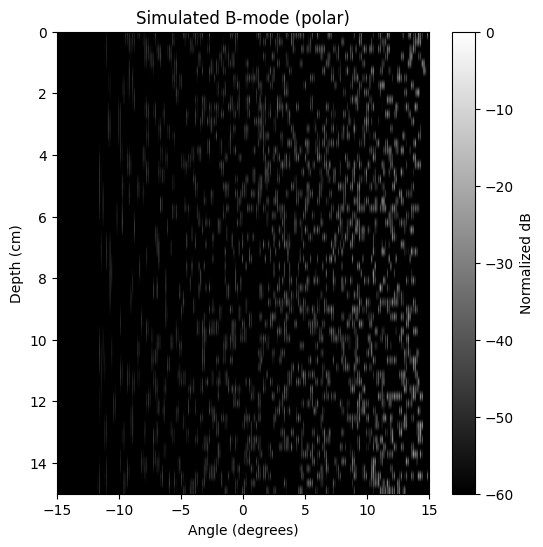

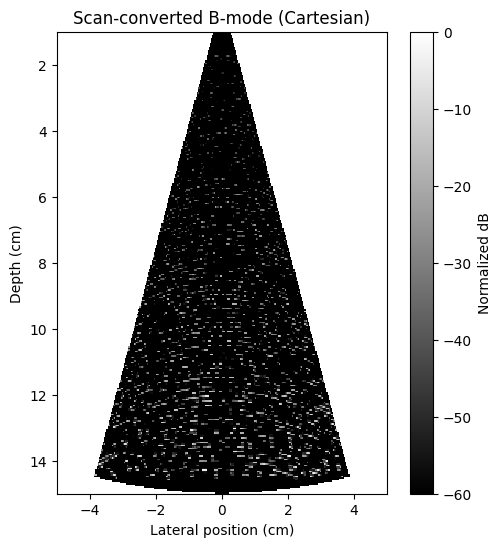

In [ ]:
from scipy.signal import hilbert
from scipy.interpolate import griddata
# TODO: Create synthetic scattering phantom using point scatterers
nx, ny = 200, 200
x = np.linspace(-0.05, 0.05, nx)  
y = np.linspace(0.01, 0.15, ny)  
X, Y = np.meshgrid(x, y)

phantom = np.zeros((ny, nx))

rng = np.random.default_rng(0)

n_scatterers = 3000
scatterer_x = rng.uniform(-0.04, 0.04, n_scatterers)
scatterer_y = rng.uniform(0.015, 0.145, n_scatterers)
scatterer_amp = rng.uniform(0.3, 1.0, n_scatterers)

for x_s, y_s, a_s in zip(scatterer_x, scatterer_y, scatterer_amp):
    ix = np.argmin(np.abs(x - x_s))
    iy = np.argmin(np.abs(y - y_s))
    phantom[iy, ix] += a_s

strong_targets = [
    (-0.015, 0.08, 2.0),
    (0.02, 0.12, 1.8),
    (-0.03, 0.10, 1.5)
]

for strong_x, strong_y, strong_amp in strong_targets:
    ix = np.argmin(np.abs(x - strong_x))
    iy = np.argmin(np.abs(y - strong_y))
    phantom[iy, ix] += strong_amp

# TODO: Simulate RF echo data for each scanline
c = 1540  
f0 = 5e6  
wavelength = c / f0

n_scan = 64
angles = np.linspace(-15, 15, n_scan)

n_depth = 200
depths = np.linspace(0.01, 0.15, n_depth)

fs = 40e6  
max_time = 2 * depths[-1] / c
nt = int(np.ceil(max_time * fs)) + 1

t = np.arange(nt) / fs

pulse_len = int(np.round(2 * fs / f0))
pulse_time = np.arange(pulse_len) / fs
pulse = np.sin(2 * np.pi * f0 * pulse_time) * np.hanning(pulse_len)

round_trip_time = 2 * depths / c
round_trip_idx = (round_trip_time * fs).astype(int)

rf_data = np.zeros((n_scan, nt))


x_grid = x
y_grid = y

for i, theta in enumerate(angles):
    theta_rad = np.deg2rad(theta)
    
    xs = depths * np.sin(theta_rad)
    ys = depths * np.cos(theta_rad)

    reflectivity = np.zeros_like(depths)

    for j in range(len(depths)):
        if x_grid[0] <= xs[j] <= x_grid[-1] and y_grid[0] <= ys[j] <= y_grid[-1]:
            row_idx = np.searchsorted(y_grid, ys[j])
            row_idx = np.clip(row_idx, 1, ny - 1)

            y0, y1 = y_grid[row_idx - 1], y_grid[row_idx]
            w = (ys[j] - y0) / (y1 - y0 + 1e-12)

            row0 = phantom[row_idx - 1, :]
            row1 = phantom[row_idx, :]

            val0 = np.interp(xs[j], x_grid, row0)
            val1 = np.interp(xs[j], x_grid, row1)

            reflectivity[j] = (1 - w) * val0 + w * val1

    for j, amp in enumerate(reflectivity):
        start = round_trip_idx[j]
        if start < nt:
            end = min(nt, start + pulse_len)
            rf_data[i, start:end] += amp * pulse[: end - start]

# TODO: Apply envelope detection to extract amplitude from RF signal
analytic_signal = hilbert(rf_data, axis=1)
env = np.abs(analytic_signal)

# TODO: Apply time-gain compensation (TGC)
alpha_db_cm = 0.5 * (f0 / 1e6) 

depth_time = (c * t) / 2 
depth_cm = depth_time * 100

gain = 10 ** ((alpha_db_cm * depth_cm) / 20)
env_tgc = env * gain[np.newaxis, :]

# TODO: Apply log compression (dB scale)
env_tgc /= np.max(env_tgc) + 1e-12
img_db = 20 * np.log10(env_tgc + 1e-12)

dynamic_range = 60
img_db = np.clip(img_db, -dynamic_range, 0)

print(f"Image dB range: {img_db.min():.2f} to {img_db.max():.2f} dB")

# TODO: Display and analyze reconstructed B-mode image
plt.figure(figsize=(6, 6))
plt.imshow(
    img_db,
    extent=[angles[0], angles[-1], depth_cm[-1], depth_cm[0]],
    aspect='auto',
    cmap='gray',
    vmin = -60,
    vmax = 0        
)
plt.xlabel('Angle (degrees)')
plt.ylabel('Depth (cm)')
plt.title('Simulated B-mode (polar)')
plt.colorbar(label='Normalized dB')
plt.show()

# TODO: Perform scan conversion (polar to Cartesian)
x_cart = np.linspace(-0.05, 0.05, 300)   
y_cart = np.linspace(0.01, 0.15, 300)    
Xc, Yc = np.meshgrid(x_cart, y_cart)

R = np.sqrt(Xc**2 + Yc**2)
Theta = np.rad2deg(np.arctan2(Xc, Yc))   

img_cart = np.full_like(Xc, np.nan, dtype=float)

r_axis = depth_time[:img_db.shape[1]]

theta_idx = np.interp(Theta, angles, np.arange(len(angles)))
r_idx = np.interp(R, r_axis, np.arange(len(r_axis)))

theta_idx = np.round(theta_idx).astype(int)
r_idx = np.round(r_idx).astype(int)

valid = (
    (Theta >= angles[0]) & (Theta <= angles[-1]) &
    (R >= r_axis[0]) & (R <= r_axis[-1]) &
    (theta_idx >= 0) & (theta_idx < len(angles)) &
    (r_idx >= 0) & (r_idx < len(r_axis))
)

img_cart[valid] = img_db[theta_idx[valid], r_idx[valid]]

plt.figure(figsize=(6, 6))
plt.imshow(
    img_cart,
    extent=[x_cart[0] * 100, x_cart[-1] * 100, y_cart[-1] * 100, y_cart[0] * 100],
    cmap='gray',
    vmin=-60,
    vmax=0,
    interpolation='nearest',
)
plt.xlabel('Lateral position (cm)')
plt.ylabel('Depth (cm)')
plt.title('Scan-converted B-mode (Cartesian)')
plt.colorbar(label='Normalized dB')
plt.show()


## 3.3 Shepp-Logan Phantom Reconstruction

### **Coding Exercise 4**

Validate your B-mode reconstruction pipeline from **Coding Exercise 3** by applying it to a **Shepp-Logan digital phantom**. This simulates a more realistic imaging scenario with defined tissue-like features, allowing you to assess how well your algorithm handles anatomically-plausible structures compared to the simple synthetic scatterers in Exercise 3.

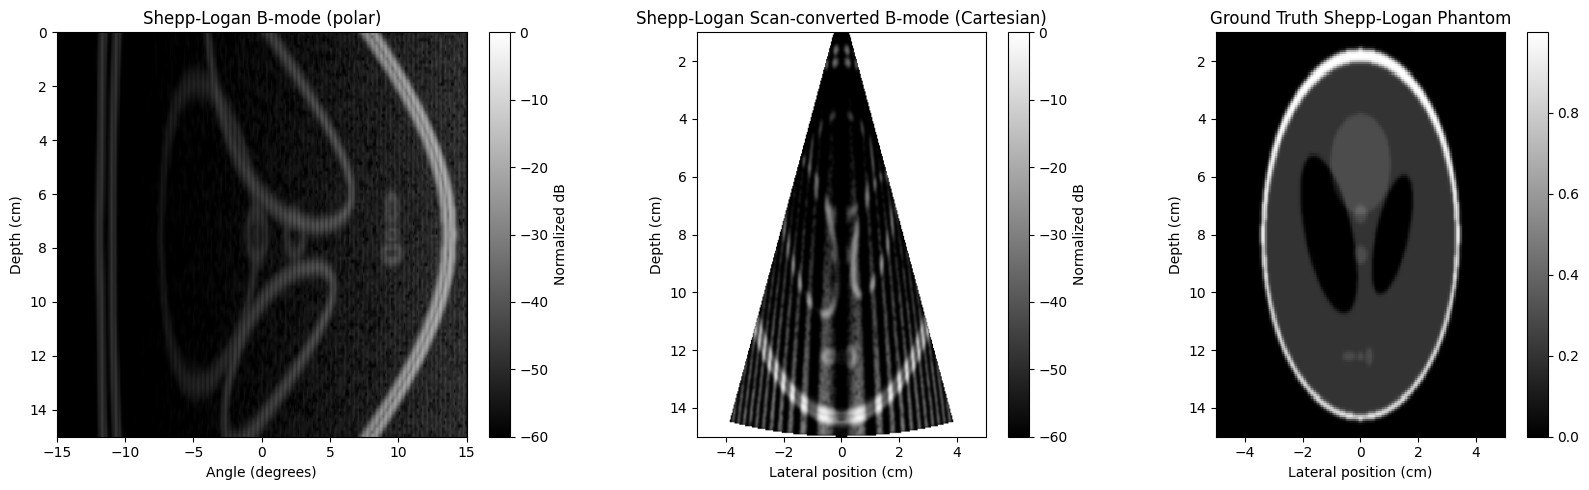

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from skimage.data import shepp_logan_phantom

nx, ny = 200, 200
x = np.linspace(-0.05, 0.05, nx)  
y = np.linspace(0.01, 0.15, ny)  

# TODO: Load Shepp-Logan phantom
phantom_sl = shepp_logan_phantom()

x_sl = np.linspace(-0.05, 0.05, phantom_sl.shape[1])
y_sl = np.linspace(0.01, 0.15, phantom_sl.shape[0])

interp_func = RegularGridInterpolator(
    (y_sl, x_sl), 
    phantom_sl, 
    method='linear', 
    bounds_error=False, 
    fill_value=0)

X, Y = np.meshgrid(x, y)
points = np.stack([Y.ravel(), X.ravel()], axis=-1)
phantom = interp_func(points).reshape((len(y), len(x)))
phantom = gaussian_filter(phantom, sigma=1)

gy, gx = np.gradient(phantom, y, x, edge_order=1)
reflectivity_2d = np.sqrt(gx**2 + gy**2)

reflectivity_2d /= reflectivity_2d.max() + 1e-12
rng = np.random.default_rng(0)
speckle = 0.03 * rng.random(reflectivity_2d.shape)
reflectivity_2d = np.clip(reflectivity_2d + speckle, 0, 1)

# TODO: Apply your reconstruction pipeline from Exercise 3 to this phantom

c = 1540  
f0 = 5e6  
wavelength = c / f0

n_scan = 128
angles = np.linspace(-15, 15, n_scan)

n_depth = 300
depths = np.linspace(0.01, 0.15, n_depth)

fs = 40e6  
max_time = 2 * depths[-1] / c
nt = int(np.ceil(max_time * fs)) + 1

t = np.arange(nt) / fs

pulse_len = int(np.round(2 * fs / f0))
pulse_time = np.arange(pulse_len) / fs
pulse = np.sin(2 * np.pi * f0 * pulse_time) * np.hanning(pulse_len)

round_trip_time = 2 * depths / c
round_trip_idx = (round_trip_time * fs).astype(int)

rf_data = np.zeros((n_scan, nt))

x_grid = x
y_grid = y

for i, theta in enumerate(angles):
    theta_rad = np.deg2rad(theta)
    
    xs = depths * np.sin(theta_rad)
    ys = depths * np.cos(theta_rad)

    reflectivity = np.zeros_like(depths)

    for j in range(len(depths)):
        if x_grid[0] <= xs[j] <= x_grid[-1] and y_grid[0] <= ys[j] <= y_grid[-1]:
            row_idx = np.searchsorted(y_grid, ys[j])
            row_idx = np.clip(row_idx, 1, ny - 1)

            y0, y1 = y_grid[row_idx - 1], y_grid[row_idx]
            w = (ys[j] - y0) / (y1 - y0 + 1e-12)

            row0 = reflectivity_2d[row_idx - 1, :]
            row1 = reflectivity_2d[row_idx, :]

            val0 = np.interp(xs[j], x_grid, row0)
            val1 = np.interp(xs[j], x_grid, row1)

            reflectivity[j] = (1 - w) * val0 + w * val1

    for j, amp in enumerate(reflectivity):
        start = round_trip_idx[j]
        if start < nt:
            end = min(nt, start + pulse_len)
            rf_data[i, start:end] += amp * pulse[: end - start]

analytic_signal = hilbert(rf_data, axis=1)
env = np.abs(analytic_signal)

alpha_db_cm = 0.5 * (f0 / 1e6) 

depth_time = (c * t) / 2 
depth_cm = depth_time * 100

gain = 10 ** ((alpha_db_cm * depth_cm) / 20)
env_tgc = env * gain[np.newaxis, :]

env_tgc /= np.max(env_tgc) + 1e-12
img_db = 20 * np.log10(env_tgc + 1e-12)

dynamic_range = 60
img_db = np.clip(img_db, -dynamic_range, 0)

x_cart = np.linspace(-0.05, 0.05, 300)   
y_cart = np.linspace(0.01, 0.15, 300)    
Xc, Yc = np.meshgrid(x_cart, y_cart)

R = np.sqrt(Xc**2 + Yc**2)
Theta = np.rad2deg(np.arctan2(Xc, Yc))   

img_cart = np.full_like(Xc, np.nan, dtype=float)

r_axis = depth_time[:img_db.shape[1]]

theta_idx = np.interp(Theta, angles, np.arange(len(angles)))
r_idx = np.interp(R, r_axis, np.arange(len(r_axis)))

theta_idx = np.round(theta_idx).astype(int)
r_idx = np.round(r_idx).astype(int)

valid = (
    (Theta >= angles[0]) & (Theta <= angles[-1]) &
    (R >= r_axis[0]) & (R <= r_axis[-1]) &
    (theta_idx >= 0) & (theta_idx < len(angles)) &
    (r_idx >= 0) & (r_idx < len(r_axis))
)

img_cart[valid] = img_db[theta_idx[valid], r_idx[valid]]

img_cart_filled = np.where(np.isnan(img_cart), -60, img_cart)
img_cart_smoothed = gaussian_filter(img_cart_filled, sigma=1)
img_cart_smoothed[np.isnan(img_cart)] = np.nan

# TODO: Compare reconstructed image quality with ground truth
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

image1 = axes[0].imshow(
    img_db,
    extent=[angles[0], angles[-1], depth_cm[-1], depth_cm[0]],
    aspect='auto',
    cmap='gray',
    vmin=-60,
    vmax=0        
)
axes[0].set_xlabel('Angle (degrees)')
axes[0].set_ylabel('Depth (cm)')
axes[0].set_title('Shepp-Logan B-mode (polar)')
fig.colorbar(image1, ax=axes[0], fraction=0.046, label='Normalized dB')

image2 = axes[1].imshow(
    img_cart_smoothed,
    extent=[x_cart[0] * 100, x_cart[-1] * 100, y_cart[-1] * 100, y_cart[0] * 100],
    cmap='gray',
    vmin=-60,
    vmax=0,
    interpolation='bilinear',
)
axes[1].set_xlabel('Lateral position (cm)')
axes[1].set_ylabel('Depth (cm)')
axes[1].set_title('Shepp-Logan Scan-converted B-mode (Cartesian)')
fig.colorbar(image2, ax=axes[1], fraction=0.046, label='Normalized dB')

image3 = axes[2].imshow(
    phantom,
    extent=[x[0] * 100, x[-1] * 100, y[-1] * 100, y[0] * 100],
    cmap='gray',
    interpolation='nearest',
)
axes[2].set_xlabel('Lateral position (cm)')
axes[2].set_ylabel('Depth (cm)')
axes[2].set_title('Ground Truth Shepp-Logan Phantom')
fig.colorbar(image3, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

### **Analysis**

Compare reconstructed image with the ground truth phantom. Assess image quality and artifacts introduced by the ultrasound imaging process

In [ ]:
# the reconstructed B-mode image is able to preserve the overall structure of the
# Shepp-Logan phantom, with the main internal features and boundaries being visible. 
# however, the reconstructed image seems to be affected by speckle noise and is less
# sharply defined in comparison, this is evident in the broadening of the edges and
# reduced contrast in smaller features.
# the imaging process introduces multiple artifacts that degrade the quality of the
# scan-converted image, including:
    # vertical scanline patterns due to the finite number of beam angles and limited
    # lateral sampling, which can create streaks and reduce the clarity of structures.
    # in the polar image, structures appear curved most likely beause the data was 
    # acquired in angle-depth coordinates prior to scan conversion, which can lead to
    # distortion of features when mapped to Cartesian coordinates.
    # the speckle-like texture and intensity variations are likely due to the simulated
    # scattering model used and envelope detection, which can introduce granular noise
    # that obscures fine details, reducing contrast.

## 3.4 Signal Processing & Dynamic Range

### **Questions 10**
Received RF echo signal ranges from -50 mV to +50 mV. After envelope detection and TGC, dynamic range is 0.1–100 mV (1000:1 or ~60 dB).
- a) Why does linear display (0–100 scale) make weak signals invisible?
- b) Apply log compression. What is the resulting dB range?
- c) With 8-bit display (0–255 levels), how many dB per level? Sufficient for 3 dB myocardial contrast differences?
- d) How does 16-bit display depth improve visualization of subtle tissue differences?

In [ ]:
# Question 10 - Answers
# a)
    # with a linear display, the strongest echoes would occupy most of the display
    # range, while the weaker ones would end up squeezed into a few low-intensity
    # levels and not represented meaningfully. the dynamic range of 0.1-100mV means
    # the largest signals are ~1000x larger than the smallest, and because a linear
    # display skews toward the larger values, any low-amplitude echoes recieved 
    # would appear nearly black/invisible and hard to distinguish from one another
    # making subtle differences in tissues harder to see/easier to lose.
# b)
# dynamic range = 0.1-100 mV
   # Strongest signal:
    # dB = 20 log10(l2/l1)
    # dB = 20 log10(100/0.1)
    # dB = 20 log10(1000)
    # dB = 60
   # Weakest signal:
    # dB = 20 log10(l2/l1)
    # dB = 20 log10(0.1/0.1)
    # dB = 20 log10(1)
    # dB = 0
# resulting range = 0 - 60 dB

# Part 4: Doppler Imaging & Artifact Analysis

---

## Key Concepts

**Doppler Shift:** Frequency change from moving targets (blood flow)
- Δf = 2f₀·v·cos(θ)/c — factor of 2 because sound travels to target and returns
- Only velocity component along beam (cos(θ)) contributes; perpendicular motion is invisible
- v_max = c·PRF / (4f₀·cos(θ)) [Nyquist limit for pulsed Doppler] — velocities above this exceed sampling rate
- Below Nyquist: velocity measured correctly; above Nyquist: aliasing occurs (velocity appears reversed)

**Artifacts:** Misinterpretation of ultrasound signal caused by physics assumptions
- **Shadowing:** Strong attenuator (bone, gas) blocks transmission → dark (anechoic) region directly behind
- **Enhancement:** Low-attenuation region (fluid-filled cyst) allows more signal → bright region directly behind  
- **Mirror Image:** Reflection off strong smooth surface (diaphragm, bone) creates false duplicate structure on opposite side
- **Reverberation:** Multiple bounces between two strong reflectors → equally-spaced ghost echoes
- **Speckle:** Inherent grainy texture from constructive/destructive interference of scattered signals — characteristic ultrasound appearance

## 4.1 Pulsed-Doppler Velocity Measurement

### **Questions 11**

A 5 MHz pulsed-Doppler system measures blood flow in the carotid artery.
- a) A red blood cell moving at 0.8 m/s toward the transducer causes a Doppler shift. Calculate shift frequency (assume 60° angle, c = 1540 m/s)
- b) System has PRF = 6 kHz. Calculate the Nyquist velocity limit.
- c) Can you measure 0.8 m/s without aliasing?
- d) What PRF is needed to measure 1.5 m/s at 60° angle without aliasing?

### **Questions 12**
In severe carotid stenosis, peak systolic velocity reaches 4 m/s.
- a) Can standard PW Doppler (PRF ~ 8 kHz, f = 5 MHz, θ = 60°) measure this without aliasing?
- b) What is the maximum velocity this system can measure?
- c) How would you modify the system for higher velocities? What are the trade-offs?

## 4.2 Artifact Identification & Mitigation

### **Coding Exercise 5**

**PART A:**
Load your reconstructed B-mode image from **Coding Exercise 3 or 4** and analyze what artifacts you actually see:

1. **Identify present artifacts:** Examine speckle patterns, reconstruction artifacts (ringing, aliasing), any other visual anomalies
2. **Characterize severity:** Describe the magnitude, spatial distribution, and impact on image quality
3. **Quantify where possible:** Calculate speckle statistics, measure artifact extent, assess signal-to-noise
4. **Visual documentation:** Display the image and annotate observed artifacts

**PART B:** Choose **one** artifact type that was NOT naturally present in your reconstructed image.

1. **Inject the artifact** synthetically onto your reconstructed imageFor your chosen artifact, create:
2. **Implement a detector** for that artifact type
3. **Test sensitivity:** Vary artifact parameters and measure detection performance5. **Assess trade-offs:** Show what detail is preserved vs. what is lost
4. **Implement mitigation** to reduce the artifact

In [ ]:
# PART A: Analyze Natural Artifacts
# TODO: Load your reconstructed B-mode image from Exercise 3 or 4
# ...

# TODO: Identify and characterize artifacts present in your image
# ...

# TODO: Quantify artifact properties (speckle statistics, artifact extent, etc.)
# ...

# PART B: Inject Your Choice of Artifact
# TODO: Choose one artifact type (shadowing, enhancement, reverberation, or other)
# ...

# TODO: Synthetically inject the artifact onto your reconstructed image
# ...

# TODO: Implement a detector for your chosen artifact
# ...

# TODO: Test detector performance and implement mitigation
# ...


## 4.3 Clinical Artifact Case Studies

### **Questions 13**

You observe a dark (anechoic) structure within the gallbladder at 5 cm depth with a bright acoustic shadow extending below it.
- a) Is this definitely a gallstone? Explain the physical basis of the shadow.
- b) Could it be a polyp instead? What would distinguish them on ultrasound?

### **Questions 14**

You observe a round, dark (anechoic) mass at 8 cm depth with a bright region immediately behind it.
- a) Is this definitely a cyst? Could it be a hypoechoic solid tumor instead?
- b) Explain the physics of acoustic enhancement behind fluid-filled structures.

---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable3.ipynb` and `.pdf`

**Due:** Monday, March 16, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Coding Exercises Due |
|---------|--------------------------------|
| **Part 1: Acoustic Physics & Tissue Interactions** | Q1 (a,b,c), Q2 (a,b,c,d), Coding Exercise 1, Q3 (a,b), Q4 (a,b,c) |
| **Part 2: Transducers & Beam Forming** | Q5 (a,b,c,d), Q6 (a,b,c), Coding Exercise 2, Q7 (a,b,c,d) |
| **Part 3: Image Formation & Reconstruction** | Q8 (a,b,c,d), Q9 (a,b,c,d), Coding Exercise 3, Coding Exercise 4 + Analysis, Q10 (a,b,c,d) |
| **Part 4: Doppler Imaging & Artifact Analysis** | Q11 (a,b,c,d), Q12 (a,b,c), Coding Exercise 5, Q13 (a,b), Q14 (a,b) |
